<style>
.jp-RenderedHTMLCommon,
.text_cell_render {
  font-family: medium-content-serif-font, Georgia, Cambria, "Times New Roman", Times, serif;
  font-size: 17px;
  line-height: 1.65;
  color: #1f2328;
}
.jp-RenderedHTMLCommon h1,
.jp-RenderedHTMLCommon h2,
.jp-RenderedHTMLCommon h3,
.text_cell_render h1,
.text_cell_render h2,
.text_cell_render h3 {
  font-family: sohne, "Helvetica Neue", Helvetica, Arial, sans-serif;
  color: #111;
}
.jp-RenderedHTMLCommon h1,
.text_cell_render h1 {
  font-size: 2.6rem;
  letter-spacing: -0.03em;
}
.jp-RenderedHTMLCommon h2,
.text_cell_render h2 {
  margin-top: 1.8em;
}
</style>

# Expediente B. ¿Mercado cerrado?

Data Analytics | Semanas 7–8 | 2026-2

Este notebook acompaña la lectura ¿Qué puede decir realmente un contrato público?

Afirmación que se investigará:

En algunos grupos de contratación pública, una proporción elevada del valor contratado se concentra en pocos proveedores.

Este expediente utiliza un único archivo: `data/secop_recorte.csv`.

Durante la primera semana se construyen tres evidencias y se documentan tres decisiones de preparación. En la segunda semana se incorpora una objeción y se revisa si la conclusión inicial se mantiene.

El objetivo es que cada cifra utilizada en la conclusión pueda localizarse en el notebook y que el alcance de la afirmación corresponda a lo que realmente muestran los datos.


## Preparar los datos

Ubique el notebook junto a la carpeta `data`.

```text
Expediente_B.ipynb
data/
└── secop_recorte.csv
```

No es necesario descargar datos, seleccionar un equipo ni modificar filtros.


In [1]:
from pathlib import Path
from statistics import NormalDist
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

DATA_FILE = Path("data") / "secop_recorte.csv"

if not DATA_FILE.exists():
    raise FileNotFoundError("No se encontró data/secop_recorte.csv.")

df_raw = pd.read_csv(DATA_FILE, dtype=str)

print("Archivo:", DATA_FILE.name)
print("Filas:", f"{len(df_raw):,}")
print("Columnas:", df_raw.shape[1])


Archivo: secop_recorte.csv
Filas: 623
Columnas: 85


## Comprender el archivo antes de analizarlo

Cada fila de `secop_recorte.csv` representa un contrato incluido en el conjunto asignado al equipo. El archivo no corresponde a todo SECOP II, sino a una parte previamente seleccionada para la actividad.

La columna `ciudad`, cuando está disponible, identifica la ciudad de registro de la entidad que publica el contrato. No debe interpretarse automáticamente como el lugar físico donde se ejecutó el servicio, la obra o el suministro.

Las siguientes conversiones permiten trabajar con valores y fechas sin eliminar registros.


In [8]:
df = df_raw.copy()

for column in ["valor_del_contrato", "dias_adicionados"]:
    if column in df.columns:
        df[column] = pd.to_numeric(df[column], errors="coerce")

for column in [
    "fecha_de_firma",
    "fecha_de_inicio_del_contrato",
    "fecha_de_fin_del_contrato",
]:
    if column in df.columns:
        df[column] = pd.to_datetime(df[column], errors="coerce")

if {
    "fecha_de_inicio_del_contrato",
    "fecha_de_fin_del_contrato",
}.issubset(df.columns):
    df["duracion_dias"] = (
        df["fecha_de_fin_del_contrato"]
        - df["fecha_de_inicio_del_contrato"]
    ).dt.days

if {"valor_del_contrato", "duracion_dias"}.issubset(df.columns):
    months = df["duracion_dias"] / 30.44
    df["valor_mensual_equivalente"] = (
        df["valor_del_contrato"] / months.where(months > 0)
    )

sample_columns = [
    c for c in [
        "id_contrato",
        "nombre_entidad",
        "ciudad",
        "proveedor_adjudicado",
        "tipo_de_contrato",
        "modalidad_de_contratacion",
        "valor_del_contrato",
        "fecha_de_firma",
    ]
    if c in df.columns
]

df[sample_columns].head(3)


,id_contrato,nombre_entidad,ciudad,proveedor_adjudicado,tipo_de_contrato,modalidad_de_contratacion,valor_del_contrato,fecha_de_firma
0,CO1.PCCNTR.5962208,ALCALDIA MUNICIPAL DE LA VICTORIA VALLE,No Definido,JOSE DAGO SILVA,Prestación de servicios,Contratación directa,8336000.0,2024-02-19
1,CO1.PCCNTR.7952079,GOBERNACION DEL VALLE DEL CAUCA - SECRETARIA D...,Cali,Maria del Pilar Gomez Ramirez,Prestación de servicios,Contratación directa,4000000.0,2025-06-06
2,CO1.PCCNTR.8034377,SANTIAGO DE CALI DISTRITO ESPECIAL - SECRETARI...,Cali,GENARO QUIÑONES TENORIO,Prestación de servicios,Contratación directa,16110000.0,2025-07-03


### Antes de seguir

1. ¿Qué representa una fila?
* Un contrato.
2. ¿Qué información permite identificar a la entidad y al proveedor?
* Las columnas 2 y 4 permiten conocer el nombre de la entidad y el proveedor al que se le adjudico dicho contrato.
3. ¿Qué variable monetaria aparece en el archivo?
* El valor del contrato en COP.
4. ¿Qué variable o columna necesita comprender mejor antes de utilizarla?
* El tipo de Contrato, ya que incluye decretos y casos de "Otros", y la modalidad de la contratación, debido a la variedad de contratos que se pueden firmar entre las partes.


## Primera semana: describir el conjunto asignado

La primera revisión se concentra en `valor_del_contrato`. Se estudiará una variable por separado antes de introducir comparaciones entre grupos.

La media, la mediana y los percentiles no responden exactamente la misma pregunta. Si la distribución contiene unos pocos contratos de valor muy alto, la media puede alejarse considerablemente de la mediana.


In [14]:
if "valor_del_contrato" not in df.columns:
    raise KeyError("El archivo no contiene la columna valor_del_contrato.")

contract_value = df["valor_del_contrato"].dropna()

value_summary = pd.Series({
    "contratos con valor registrado": len(contract_value),
    "media": contract_value.mean(),
    "mediana": contract_value.median(),
    "moda": contract_value.mode().iloc[0],
    "percentil 25": contract_value.quantile(0.25),
    "percentil 75": contract_value.quantile(0.75),
    "percentil 90": contract_value.quantile(0.90),
    "mínimo": contract_value.min(),
    "máximo": contract_value.max(),
    "contratos con valor 0": int((contract_value == 0).sum()),
})

value_summary.to_frame("resultado").style.format('{:,.0f}')

,resultado
contratos con valor registrado,623
media,"58,850,118"
mediana,"12,000,000"
moda,"12,000,000"
percentil 25,"7,700,000"
percentil 75,"22,711,500"
percentil 90,"45,783,936"
mínimo,0
máximo,"8,605,955,082"
contratos con valor 0,1


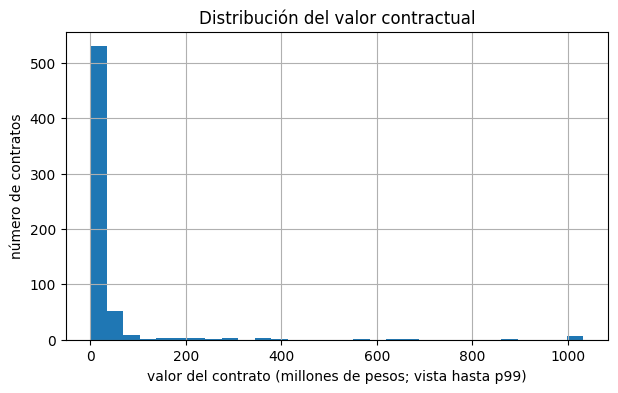

In [13]:
upper_view = contract_value.quantile(0.99)

plt.figure(figsize=(7, 4))
(contract_value.clip(upper=upper_view) / 1_000_000).hist(bins=30)
plt.xlabel("valor del contrato (millones de pesos; vista hasta p99)")
plt.ylabel("número de contratos")
plt.title("Distribución del valor contractual")
plt.show()


### Deténgase y revise

1. ¿La media y la mediana son semejantes o muy diferentes?
* La mediana describe un valor "bajo" mientras que la media es de un valor mucho mas alto.
2. ¿Cuál de las dos describe mejor un contrato típico dentro de estos datos?
* La medianda describe el valor de la mitad de la totalidad de los contratos.
3. ¿Qué muestra el histograma sobre la forma de la distribución?
* Es una distribución agrupada hacia la izquierda, lo que indica que los valores tipicos rondan los valores bajos.
4. ¿Por qué limitar la escala visual al percentil 99 no equivale a eliminar esos contratos del análisis?
* Hace el analisis de la escala mucho mas comodo mientras se tiene en cuenta todos los contratos sin la necesidad de eliminarlos.


## Revisar la calidad antes de preparar los datos

Un faltante, un valor en cero, una repetición o un valor extremo no se elimina automáticamente. Primero debe establecerse si afecta la pregunta que se quiere responder.

La siguiente revisión muestra aspectos que pueden modificar las conclusiones.


In [15]:
quality_columns = [
    c for c in [
        "id_contrato",
        "nombre_entidad",
        "ciudad",
        "proveedor_adjudicado",
        "documento_proveedor",
        "valor_del_contrato",
        "fecha_de_inicio_del_contrato",
        "fecha_de_fin_del_contrato",
        "duracion_dias",
    ]
    if c in df.columns
]

quality = pd.DataFrame({
    "faltantes": df[quality_columns].isna().sum(),
    "porcentaje_faltante": (df[quality_columns].isna().mean() * 100).round(1),
    "valores_unicos": df[quality_columns].nunique(dropna=True),
})

display(quality)

if "id_contrato" in df.columns:
    print(
        "IDs de contrato repetidos:",
        int(df["id_contrato"].duplicated(keep=False).sum())
    )

q1, q3 = df["valor_del_contrato"].quantile([0.25, 0.75])
iqr = q3 - q1
upper_iqr = q3 + 1.5 * iqr

print("Contratos con valor 0:", int((df["valor_del_contrato"] == 0).sum()))
print(
    "Posibles valores extremos según 1.5 × IQR:",
    int((df["valor_del_contrato"] > upper_iqr).sum())
)

if "duracion_dias" in df.columns:
    invalid_duration = (
        df["duracion_dias"].isna()
        | (df["duracion_dias"] <= 0)
    ).sum()
    print("Duraciones faltantes o no positivas:", int(invalid_duration))


,faltantes,porcentaje_faltante,valores_unicos
id_contrato,0,0.0,623
nombre_entidad,0,0.0,144
ciudad,0,0.0,29
proveedor_adjudicado,0,0.0,617
documento_proveedor,0,0.0,616
valor_del_contrato,0,0.0,366
fecha_de_inicio_del_contrato,5,0.8,337
fecha_de_fin_del_contrato,0,0.0,121
duracion_dias,5,0.8,243


IDs de contrato repetidos: 0
Contratos con valor 0: 1
Posibles valores extremos según 1.5 × IQR: 64
Duraciones faltantes o no positivas: 6


### Comprobar si una decisión cambia el resultado

Antes de decidir qué hacer con los valores en cero o con los contratos más altos, conviene observar cuánto cambia una estadística sencilla.

La siguiente comparación no prescribe una limpieza. Su función es mostrar si la mediana resulta sensible a tres formas distintas de preparar el valor contractual.


In [16]:
medians = {}

all_values = df["valor_del_contrato"].dropna()
if len(all_values):
    medians["sin retirar ceros"] = all_values.median()

positive_values = df.loc[
    df["valor_del_contrato"] > 0,
    "valor_del_contrato"
].dropna()

if len(positive_values):
    medians["solo valores positivos"] = positive_values.median()

if len(positive_values):
    p99 = positive_values.quantile(0.99)
    below_p99 = positive_values[positive_values <= p99]
    medians["positivos, sin el 1 % superior"] = below_p99.median()

pd.Series(medians, name="mediana_valor")


,mediana_valor
sin retirar ceros,12000000.0
solo valores positivos,12000000.0
"positivos, sin el 1 % superior",12000000.0


### Tres decisiones de preparación

Documente tres decisiones que realmente se desprendan de sus datos. Para cada una, responda:

1. ¿Qué situación encontró?
2. ¿Qué tratamiento decidió aplicar?
3. ¿Qué salida del notebook respalda la decisión?
4. ¿Qué podría cambiar en la conclusión si la decisión fuera equivocada?

No es necesario que todos los equipos adopten las mismas decisiones.



### Decisión 1: Manejo de valores faltantes en columnas clave

1.  **Situación encontrada:** Columnas importantes como `fecha_de_inicio_del_contrato`, `duracion_dias` y `documento_proveedor` tienen valores faltantes.
2.  **Tratamiento decidido:** Se decidió convertir a numérico los valores monetarios y de duración (cambiando los no válidos a faltantes) y luego excluirlos de los cálculos de mediana. Para identificar proveedores, se priorizó `documento_proveedor` y se usó `proveedor_adjudicado` como respaldo, eliminando luego los faltantes.
3.  **Salida del notebook que respalda la decisión:** La tabla de calidad mostraba los porcentajes de valores faltantes. Los cálculos de mediana y agrupación de proveedores se realizaron sobre datos limpios.
4.  **Qué podría cambiar en la conclusión si la decisión fuera equivocada:** La precisión de las estadísticas y la identificación de proveedores se verían comprometidas, sesgando los resultados.

### Decisión 2: Tratamiento de contratos con valor cero

1.  **Situación encontrada:** Se encontró un único contrato con `valor_del_contrato` igual a cero.
2.  **Tratamiento decidido:** Se evaluó el impacto de este valor cero en la mediana. Dado que la mediana no cambió al incluirlo o excluirlo, se decidió que no era necesario un tratamiento especial (como eliminación o imputación) para este análisis.
3.  **Salida del notebook que respalda la decisión:** El resumen de valores mostró un contrato con valor cero. La comparación de medianas (con y sin ceros) mostró el mismo resultado.
4.  **Qué podría cambiar en la conclusión si la decisión fuera equivocada:** Si hubiera más ceros, o si se analizara la media (más sensible), no tratarlos podría sesgar la interpretación del valor contractual típico.

### Decisión 3: Manejo de valores extremos en `valor_del_contrato`

1.  **Situación encontrada:** La distribución del `valor_del_contrato` es muy asimétrica, con un valor máximo extremadamente alto y la presencia de muchos posibles valores atípicos. El histograma era ilegible sin ajustar la escala.
2.  **Tratamiento decidido:** Se optó por visualizar el histograma limitando el eje superior al percentil 99 para mejorar la legibilidad, sin eliminar los contratos del análisis. Se confirmó que la mediana es robusta a estos valores extremos, ya que no cambia al excluir el 1% superior de los valores más altos.
3.  **Salida del notebook que respalda la decisión:** El resumen de valores mostró la gran diferencia entre media y mediana. El cálculo de valores extremos y la comparación de medianas confirmaron la robustez.
4.  **Qué podría cambiar en la conclusión si la decisión fuera equivocada:** Si se dependiera de la media, los valores extremos la distorsionarían. No reconocer la robustez de la mediana podría llevar a eliminaciones innecesarias de datos.

## Expediente B: concentración entre proveedores

La pregunta central es cuánto del valor contratado se concentra en los proveedores con mayor participación dentro del conjunto asignado.

Una concentración elevada describe la distribución de los contratos. Por sí sola no demuestra ausencia de competencia.


In [19]:
if "documento_proveedor" in df.columns:
    supplier_key = df["documento_proveedor"].where(
        df["documento_proveedor"].notna(),
        df.get("proveedor_adjudicado")
    )
else:
    supplier_key = df["proveedor_adjudicado"]

case_data = df.copy()
case_data["proveedor_clave"] = supplier_key

suppliers = (
    case_data.dropna(subset=["proveedor_clave"])
             .groupby("proveedor_clave")
             .agg(
                 contratos=("id_contrato", "count"),
                 valor_total=("valor_del_contrato", "sum"),
             )
             .sort_values("valor_total", ascending=False)
)

total_value = suppliers["valor_total"].sum()
suppliers["participacion_valor"] = (
    suppliers["valor_total"] / total_value * 100
    if total_value > 0 else np.nan
)

display(suppliers.head(10).style.format({
    "valor_total": "{:,.0f}",
    "participacion_valor": "{:,.1f}"
}))

print("Proveedores distintos:", len(suppliers))
print(
    "Participación del principal proveedor:",
    round(suppliers["participacion_valor"].head(1).sum(), 1),
    "%"
)
print(
    "Participación de los 5 primeros:",
    round(suppliers["participacion_valor"].head(5).sum(), 1),
    "%"
)
print(
    "Participación de los 10 primeros:",
    round(suppliers["participacion_valor"].head(10).sum(), 1),
    "%"
)

,contratos,valor_total,participacion_valor
proveedor_clave,,,
No Definido,2,"8,898,653,082",24.3
901285046,1,"2,857,142,258",7.8
901412432,2,"2,080,213,093",5.7
805016076,1,"1,432,765,522",3.9
800215293,1,"1,273,600,000",3.5
800243932,1,"1,155,000,000",3.2
901452657,1,"1,072,414,166",2.9
835000648,1,"891,568,449",2.4
900365102,1,"678,612,992",1.9


Proveedores distintos: 616
Participación del principal proveedor: 24.3 %
Participación de los 5 primeros: 45.1 %
Participación de los 10 primeros: 57.3 %


### Interpretar el resultado

1. ¿Cuántos proveedores aparecen en el conjunto?
* Los 10 proveedores con los porcentajes de participación mas altos
2. ¿Qué proporción del valor concentran los cinco principales?
* Un 45 % en valores de miles de millones de COP
3. ¿La concentración está dominada por uno o por varios proveedores?
* El proveedor principal concentra un porcentaje que iguala la suma de sus siguentes 6 proveedores; la concentración esta en el grupo de los primeros proveedores.
4. ¿Qué información adicional necesitaría para hablar de competencia?
* La calidad, los tiempos y las diferencias claves entre proveedores y sus contratos.

## Tablero de evidencia de la primera semana

Seleccione tres hallazgos. Para cada uno registre el hallazgo, la cifra o tabla que lo respalda, una interpretación posible y una duda pendiente.

La conclusión debe mantener una distinción: concentración y ausencia de competencia no significan lo mismo.


### Hallazgo 1: Distribución de los valores de los contratos

**Hallazgo:** Los valores de los contratos presentan una distribución muy asimétrica.

**Cifra que lo respalda:** Se analizaron **623 contratos**. La media fue de **58.850.118**, mientras que la mediana fue de **12.000.000** y el valor máximo alcanzó **8.605.955.082**. Además, se identificaron **64 posibles valores extremos**.

**Interpretación posible:** La diferencia entre la media y la mediana indica que algunos contratos de valor muy alto elevan considerablemente el promedio. Por ello, la mediana representa mejor el valor típico de los contratos analizados.

**Duda pendiente:** ¿Los contratos con valores excepcionalmente altos corresponden a necesidades o tipos de contratación diferentes que expliquen su magnitud?

### Hallazgo 2: Concentración del valor contratado

**Hallazgo:** Una parte importante del valor contratado está concentrada en un grupo reducido de proveedores.

**Cifra que lo respalda:** Se identificaron **616 proveedores distintos**. El proveedor principal concentra el **24,3 %** del valor contratado, los **5 principales concentran el 45,1 %** y los **10 principales el 57,3 %**.

**Interpretación posible:** Aunque existe un número amplio de proveedores, una proporción considerable del valor económico se concentra en los proveedores con mayor participación.

**Duda pendiente:** ¿Esta concentración se explica por algunos contratos excepcionalmente grandes o existe una diferencia sistemática en las oportunidades de contratación entre proveedores?

### Hallazgo 3: Calidad y completitud de los datos

**Hallazgo:** Se encontraron algunos registros con información faltante o valores que requieren revisión.

**Cifra que lo respalda:** De los **623 contratos**, **5 (0,8 %) tienen fecha de inicio faltante** y **5 (0,8 %) tienen duración faltante**. También se encontró **1 contrato con valor 0** y **0 IDs de contrato repetidos**.

**Interpretación posible:** Los problemas de calidad identificados son relativamente pequeños frente al total de registros, pero pueden afectar análisis específicos que dependan de fechas, duración o valores contractuales.

**Duda pendiente:** ¿Los registros con información faltante presentan alguna característica común que pueda introducir un sesgo en análisis posteriores?

## Segunda semana: poner a prueba la conclusión

Objeción de trabajo: la concentración del valor puede ser alta aunque el número de contratos esté distribuido entre muchos proveedores.

Antes de ejecutar la siguiente comparación, responda:

1. ¿Qué parte de la conclusión inicial pone en duda esta objeción?
2. ¿Por qué valor contratado y número de contratos pueden contar historias diferentes?
3. ¿Qué comparación permitiría observar esa diferencia?


In [ ]:
suppliers = suppliers.copy()

suppliers["porcentaje_valor"] = (
    suppliers["valor_total"]
    / suppliers["valor_total"].sum()
    * 100
)

suppliers["porcentaje_contratos"] = (
    suppliers["contratos"]
    / suppliers["contratos"].sum()
    * 100
)

display(
    suppliers[
        ["contratos", "valor_total", "porcentaje_valor", "porcentaje_contratos"]
    ].head(10)
)

print(
    "Cinco primeros por valor:",
    round(suppliers["porcentaje_valor"].head(5).sum(), 1),
    "%"
)
print(
    "Esos mismos cinco proveedores reúnen:",
    round(suppliers["porcentaje_contratos"].head(5).sum(), 1),
    "% de los contratos"
)


### Deténgase y revise

1. ¿La concentración por valor es semejante a la concentración por número de contratos?
2. ¿Qué cambia en la interpretación cuando ambas medidas se comparan?
3. ¿El hallazgo inicial se mantiene, se debilita o cambia?
4. ¿Qué conclusión todavía sería excesiva con estos datos?


## Asociación no significa causalidad

Cuando dos variables cambian conjuntamente, la relación puede tener varias explicaciones. Una tercera variable puede influir sobre ambas y alterar la interpretación; en estadística se habla de una variable de confusión.

Para este expediente, responda:

1. ¿Qué variable podría estar influyendo en la relación observada?
2. ¿Por qué podría modificar la interpretación?
3. ¿Qué información adicional sería necesaria para comprobarlo?


## Pensar un experimento antes de hablar de causalidad

El análisis de SECOP es observacional: trabaja con contratos que ya ocurrieron. No es un experimento A/B.

Describa una comparación ideal:

1. ¿Cuáles serían los grupos A y B?
2. ¿Qué resultado mediría?
3. ¿Sería viable asignar los grupos al azar?
4. ¿Qué diseño observacional o cuasi-experimental utilizaría si la aleatorización no fuera posible?


### Una aproximación al concepto de potencia

La potencia estadística responde una pregunta práctica: si realmente existe una diferencia de interés entre dos grupos, ¿el tamaño de muestra permite detectarla con una probabilidad razonable?

El siguiente cálculo utiliza una aproximación normal para dos grupos de igual tamaño. El propósito es observar la relación entre tamaño de efecto y tamaño de muestra.


In [ ]:
alpha = 0.05
target_power = 0.80
effect_size = 0.50

normal = NormalDist()
z_alpha = normal.inv_cdf(1 - alpha / 2)
z_power = normal.inv_cdf(target_power)

n_per_group = math.ceil(
    2 * ((z_alpha + z_power) / effect_size) ** 2
)

pd.Series({
    "alpha": alpha,
    "potencia_objetivo": target_power,
    "tamaño_de_efecto_estandarizado": effect_size,
    "n_aproximado_por_grupo": n_per_group,
})


### Antes de terminar

1. Si la diferencia de interés fuera más pequeña, ¿esperaría necesitar más o menos observaciones?
2. ¿Por qué disponer de muchas filas no corrige por sí solo un sesgo o una variable de confusión?
3. ¿Qué limitación de este expediente considera más importante después de completar la segunda semana?


## Actividad entregable

El entregable se construye a partir de la ejecución y el análisis de este notebook.

### Tablero de evidencia

Presente tres tarjetas. Cada una debe contener un hallazgo, la evidencia que lo sustenta, una interpretación posible y una duda pendiente. Las cifras deben poder localizarse en las salidas del notebook.

### Decisiones de preparación

Documente tres decisiones tomadas sobre la preparación de los datos. Para cada una indique el problema encontrado, el tratamiento aplicado, la evidencia que respalda la decisión y qué podría cambiar si esa decisión fuera incorrecta.

### Respuesta a la objeción y veredicto

Explique qué cambió después de incorporar la comparación de la segunda semana. El veredicto final debe ser uno de los siguientes:

- respaldada;
- parcialmente respaldada;
- no respaldada.

La conclusión debe incluir la principal limitación del análisis y una breve recomendación.

### Evidencia causal más fuerte

Explique qué diseño permitiría obtener evidencia causal más fuerte. Si un experimento aleatorizado no es viable, proponga una alternativa observacional o cuasi-experimental y justifique qué variable adicional sería necesario controlar.

### Declaración de uso de herramientas de inteligencia artificial

Indique la herramienta empleada, la actividad en la que se utilizó, el resultado que fue verificado y la forma de verificación, y una decisión del equipo que no se delegó a la herramienta.

El notebook entregado debe ejecutarse de principio a fin y reproducir las cifras utilizadas en el tablero y en el veredicto.

* ChatGPT: Redaccion
* Gemini: Trasnformación de Codigo